# Exploratory Data Analysis
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

In [2]:
df = pd.read_excel('../COMBINED_HORSES_DATA.xlsx')


In [3]:

print(df.head())

print(df.info())

print(df.describe(include='all'))


  Horse ID Horse name       Date                             Breed      Sex  \
0    H0001   Leonardo 2022-10-06  Warmblood (european sport horse)  Gelding   
1    H0004      Aslan 2022-10-06  Warmblood (european sport horse)  Gelding   
2    H0017   Mumsmums 2022-10-20                      Thoroughbred     Mare   
3    H0018        Shy 2022-10-20                        Pony other     Mare   
4    H0020     Robban 2022-10-20                        Pony other  Gelding   

    Age    Colour  Height  Weight  Chest girth  ...   beta_29   beta_30  \
0  14.0       Bay   171.0     690        210.0  ... -0.247215 -0.487584   
1  11.0       Bay   180.0     755        207.0  ...  0.020145 -0.555681   
2   6.0  Dark bay   162.0     519        192.0  ...  0.128218 -0.290522   
3   1.0  Chestnut    82.0      86        107.0  ... -0.672661 -0.332174   
4  14.0   Piebald   148.0     553        197.0  ... -0.053691 -0.427833   

    beta_31   beta_32   beta_33   beta_34   beta_35   beta_36   beta_37  \

---
## BCS

Mean BCS: 6.134615384615385
Std BCS: 0.8798077557655225
Min BCS: 4
Max BCS: 8
Median BCS: 6.0 2
Shapiro-Wilk Test: Statistic=0.884, p-value=0.00000


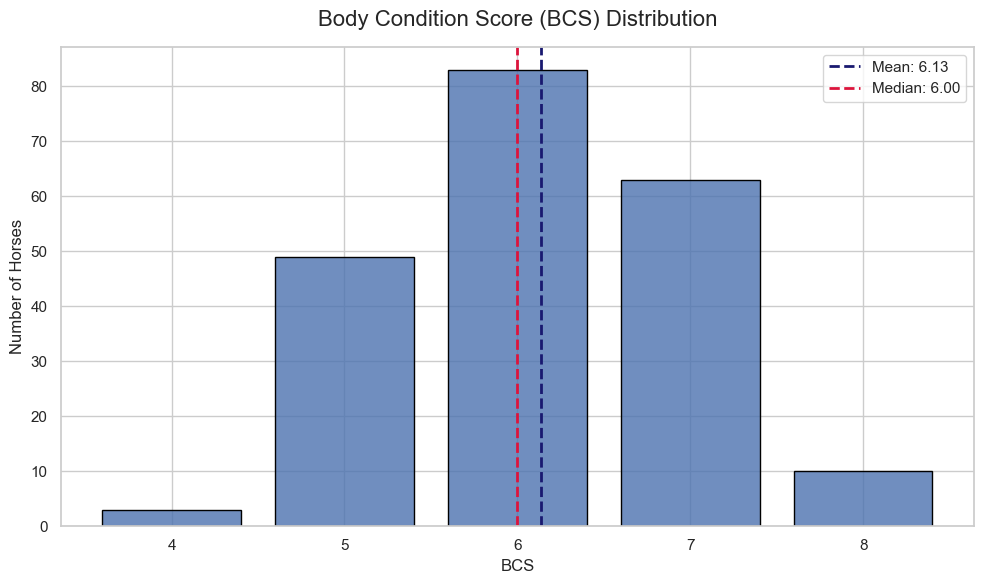

Correlation matrix:
              BCS  Height  Weight  Chest girth   Age
BCS          1.00   -0.16    0.05         0.08  0.06
Height      -0.16    1.00    0.90         0.89 -0.00
Weight       0.05    0.90    1.00         0.97  0.08
Chest girth  0.08    0.89    0.97         1.00  0.09
Age          0.06   -0.00    0.08         0.09  1.00


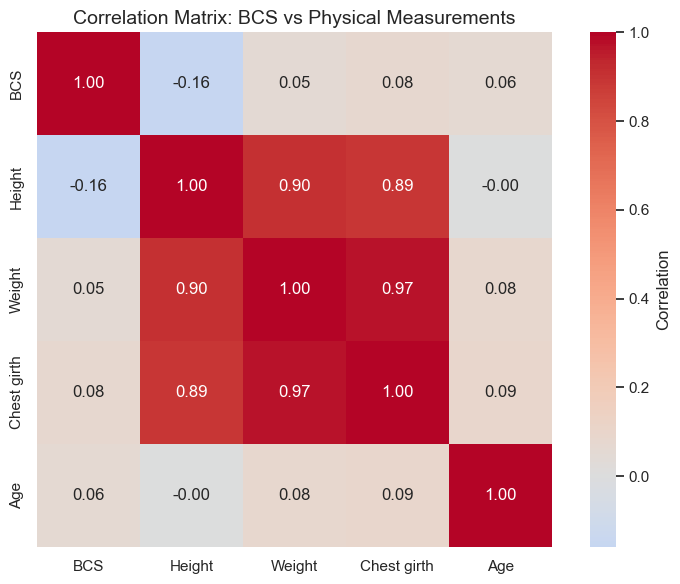

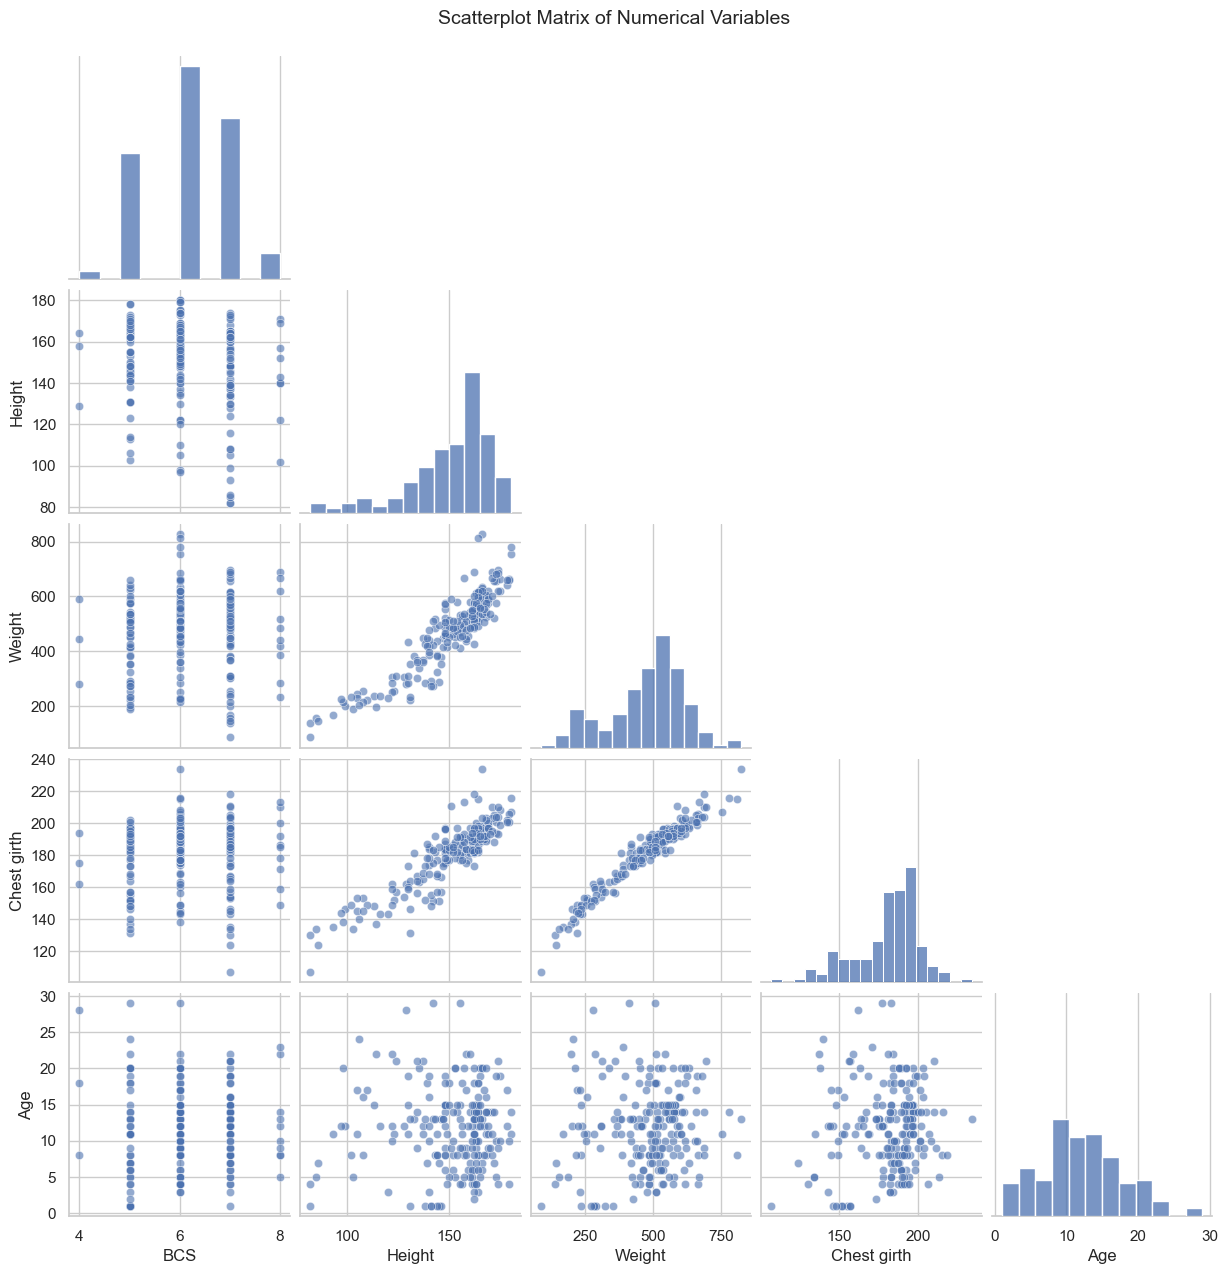


Highest mean BCS: Gelding 6.2
Lowest mean BCS : Stallion 5.67
Difference      : 0.53
Average BCS by sex:
  Stallions: 5.67 n = 9
  Geldings : 6.2 n = 112
  Mares    : 6.1 n = 87


In [4]:
# bcs descriptive statistics and distribution
print(f"Mean BCS: {df['BCS'].mean():.2f}")
print(f"Std BCS:  {df['BCS'].std():.2f}")
print(f"Min BCS:  {df['BCS'].min()}")
print(f"Max BCS:  {df['BCS'].max()}")
print(f"Median BCS: {df['BCS'].median():.2f}")

# shapiro-wilk test for normality
stat, p_value = shapiro(df['BCS'].dropna())
print(f"Shapiro-Wilk Test: Statistic={stat:.3f}, p-value={p_value:.5f}")

# compute mean and median
bcs_mean = df['BCS'].mean()
bcs_median = df['BCS'].median()

# bcs distribution plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# shrink creates visible gaps between discrete bars
sns.histplot(
    data=df,
    x='BCS',
    discrete=True,
    shrink=0.8,
    color='#4C72B0',
    edgecolor='black',
    alpha=0.8
)

plt.axvline(bcs_mean, color='midnightblue', linestyle='--', lw=2, label=f'Mean: {bcs_mean:.2f}')
plt.axvline(bcs_median, color='crimson', linestyle='--', lw=2, label=f'Median: {bcs_median:.2f}')

plt.title('Body Condition Score (BCS) Distribution', fontsize=16, pad=15)
plt.xlabel('BCS', fontsize=12)
plt.ylabel('Number of Horses', fontsize=12)

bcs_values = sorted(df['BCS'].dropna().unique())
plt.xticks(bcs_values)

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# correlation heatmap for numerical variables
numeric_cols = ['BCS', 'Height', 'Weight', 'Chest girth', 'Age']
numeric_data = df[numeric_cols]

correlation_matrix = numeric_data.corr()
print("Correlation Matrix:")
print(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix: BCS vs Physical Measurements', fontsize=14)
plt.tight_layout()
plt.show()

# paired scatterplot matrix for numerical variables
sns.pairplot(df[numeric_cols], corner=True, plot_kws={'alpha': 0.6, 'color': '#4C72B0'})
plt.suptitle('Scatterplot Matrix of Numerical Variables', y=1.02, fontsize=14)
plt.show()

# bcs by sex
sex_means = df.groupby('Sex')['BCS'].mean().sort_values()

print()
print(f"Highest Mean BCS: {sex_means.index[-1]} {round(sex_means.iloc[-1], 2)}")
print(f"Lowest Mean BCS:  {sex_means.index[0]} {round(sex_means.iloc[0], 2)}")
print(f"Difference:       {round(sex_means.iloc[-1] - sex_means.iloc[0], 2)}")

stallion_mean = df[df['Sex'] == 'Stallion']['BCS'].mean()
gelding_mean = df[df['Sex'] == 'Gelding']['BCS'].mean()
mare_mean = df[df['Sex'] == 'Mare']['BCS'].mean()

stallion_count = len(df[df['Sex'] == 'Stallion'])
gelding_count = len(df[df['Sex'] == 'Gelding'])
mare_count = len(df[df['Sex'] == 'Mare'])

print("Average BCS By Sex:")
print(f"  Stallions: {round(stallion_mean, 2)}  n = {stallion_count}")
print(f"  Geldings:  {round(gelding_mean, 2)}  n = {gelding_count}")
print(f"  Mares:     {round(mare_mean, 2)}  n = {mare_count}")


### Sub-BCS
---

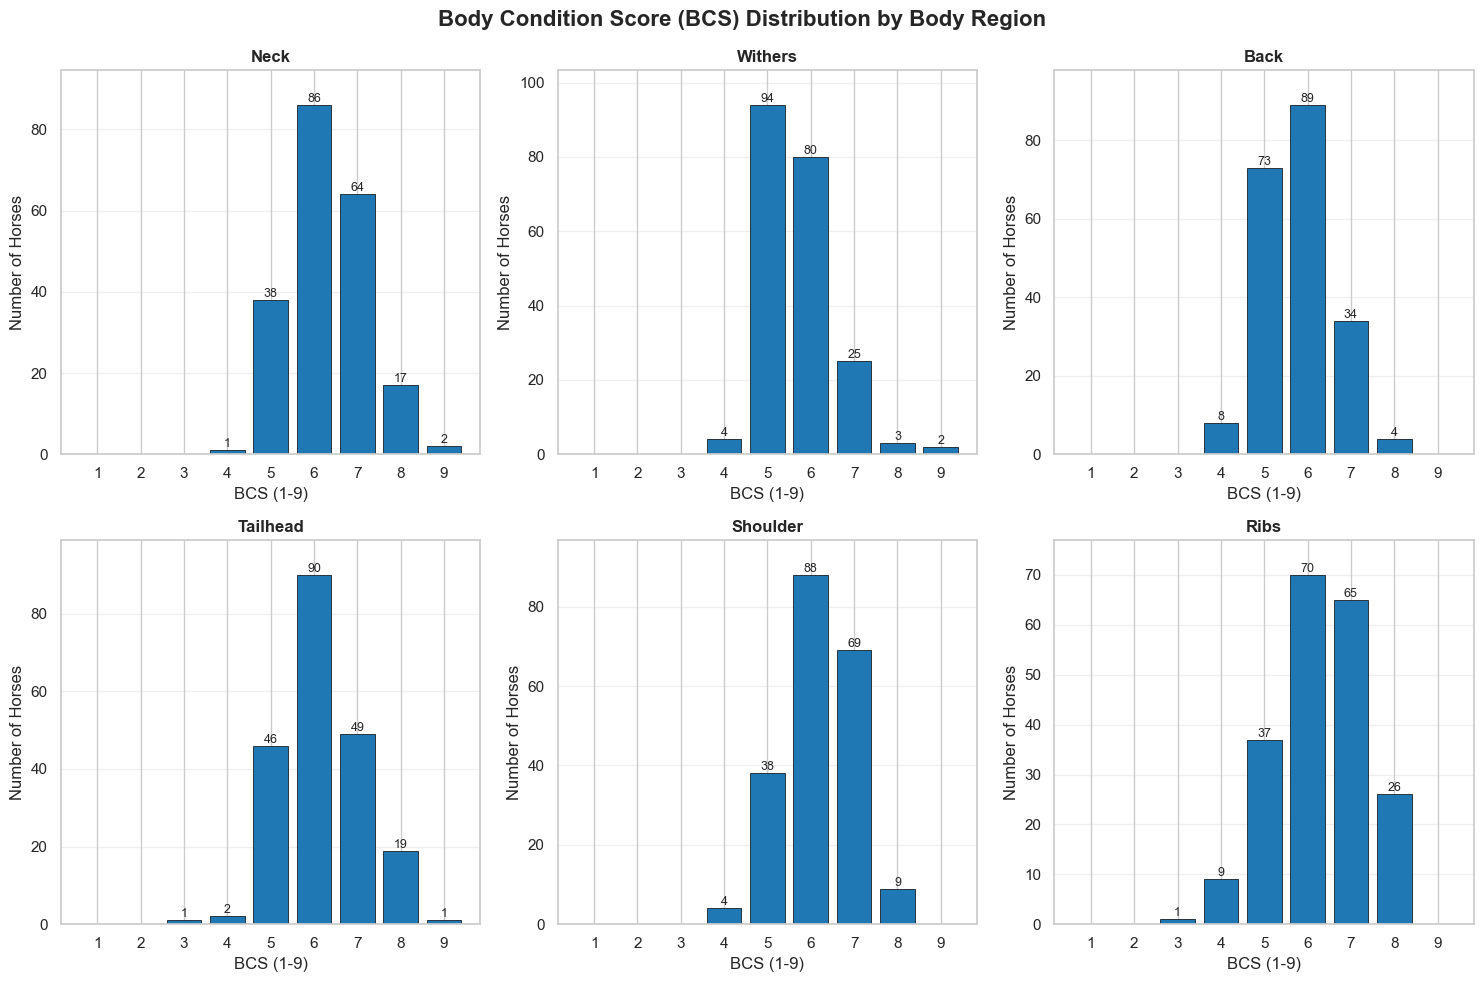

In [5]:
# sub-bcs distribution by anatomical region
bcs_columns = ['BCS_Neck', 'BCS_Withers', 'BCS_Back', 'BCS_Tailhead', 'BCS_Shoulder', 'BCS_Ribs']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Body Condition Score (BCS) Distribution by Body Region', fontsize=16, fontweight='bold')

axes = axes.flatten()
bar_color = '#1f77b4'

for idx, col in enumerate(bcs_columns):
    ax = axes[idx]

    value_counts = df[col].value_counts().sort_index()

    for i in range(1, 10):
        if i not in value_counts.index:
            value_counts[i] = 0

    value_counts = value_counts.sort_index()

    bars = ax.bar(value_counts.index, value_counts.values,
                  color=bar_color, edgecolor='black', linewidth=0.5)

    ax.set_title(f'{col.replace("BCS_", "")}', fontsize=12, fontweight='bold')
    ax.set_xlabel('BCS (1-9)')
    ax.set_ylabel('Number of Horses')
    ax.set_xticks(range(1, 10))
    ax.set_ylim(0, max(value_counts.values) * 1.1)
    ax.grid(True, alpha=0.3, axis='y')

    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
# make room for the main title
plt.subplots_adjust(top=0.92)
plt.show()


---
## Height

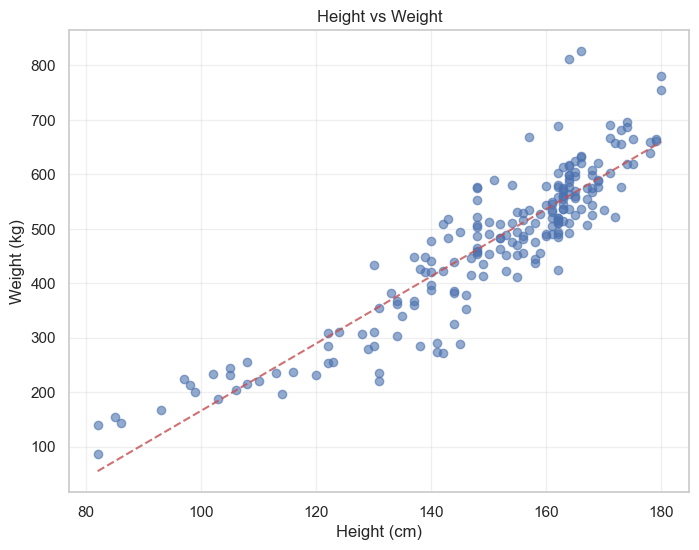

In [7]:
# height vs weight scatter plot with regression line
plt.figure(figsize=(8, 6))
plt.scatter(df['Height'], df['Weight'], alpha=0.6)
plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')

hw = df[['Height', 'Weight']].dropna()
z = np.polyfit(hw['Height'], hw['Weight'], 1)
p = np.poly1d(z)
plt.plot(hw['Height'].sort_values(), p(hw['Height'].sort_values()), "r--", alpha=0.8)

plt.grid(True, alpha=0.3)
plt.show()


---
## Sex

In [ ]:
# sex distribution pie chart
print(df['Sex'].value_counts())
df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sex Distribution')
plt.ylabel('')
plt.show()

# bcs distribution by sex
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sex', y='BCS', data=df,
            order=['Stallion', 'Gelding', 'Mare'],
            palette='Set2')
plt.title('BCS Distribution by Sex', fontsize=14)
plt.ylabel('BCS (1-9)', fontsize=12)
plt.xlabel('Sex', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## Age

In [ ]:
# age distribution histogram
plt.figure(figsize=(10, 5))
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age (year)')
plt.ylabel('Number of Horses')
plt.grid(True, alpha=0.3)
plt.show()

# boxplot to inspect age outliers
plt.boxplot(df['Age'].dropna())
plt.ylabel('Age')
plt.title('Boxplot: Age')
plt.show()


---
## Breed

In [ ]:
# breed frequency count and bar chart
breed_freq = df['Breed'].value_counts()
print(breed_freq)

plt.figure(figsize=(10, 5))
breed_freq.plot(kind='bar', color='skyblue')
plt.title('Number of Horses per Breed')
plt.xlabel('Breed')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# bcs by breed for breeds with at least 9 horses
breed_counts = df['Breed'].value_counts()
print(breed_counts)
print(len(breed_counts))
breeds_9plus = breed_counts[breed_counts >= 9].index.tolist()
print(f"Breeds With ≥9 Horses: {len(breeds_9plus)}")

print("\nMean BCS By Breed (Breeds With ≥9 Horses):")
breed_stats = df[df['Breed'].isin(breeds_9plus)].groupby('Breed')['BCS'].agg(['mean', 'std', 'count']).round(2)
print(breed_stats.sort_values('mean', ascending=False))

# percentage of horses per breed with high BCS
print("\nPercentage With High BCS (≥7) By Breed:")
for breed in breeds_9plus:
    breed_data = df[df['Breed'] == breed]
    high_pct = (breed_data['BCS'] >= 7).mean() * 100
    print(f"{breed:<35}{high_pct:5.1f}%")

# bcs value distribution per breed
for breed in breeds_9plus:
    breed_data = df[df['Breed'] == breed]
    print(f"\n{breed}:")
    print(f"  Values: {sorted(breed_data['BCS'].unique())}")
    print(f"  Count Per Value: {breed_data['BCS'].value_counts().to_dict()}")

# boxplot of bcs by breed
plt.figure(figsize=(14, 7))
sns.boxplot(x='Breed', y='BCS', data=df[df['Breed'].isin(breeds_9plus)],
            order=breeds_9plus)
plt.title('BCS Distribution by Breed (≥9 horses)', fontsize=14)
plt.ylabel('BCS (1-9)', fontsize=12)
plt.xlabel('Breed', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Ideal BCS (5)')
plt.legend()
plt.tight_layout()
plt.show()


---
## Colour

In [ ]:
# colours with at least 5 horses
colour_counts = df['Colour'].value_counts()
colours_5plus = colour_counts[colour_counts >= 5].index.tolist()

print(f"Colours With ≥5 Horses: {len(colours_5plus)}")
print("Colours:", colours_5plus)

# mean bcs per colour
print("Mean BCS By Colour (All Colours):")
colour_stats = df.groupby('Colour')['BCS'].agg(['mean', 'std', 'count']).round(2)
print(colour_stats.sort_values('mean', ascending=False))

# colour to breed association for top colours
print("Colour Distribution By Breed (For Top Colours):")

top_colours = ['Dun', 'Black', 'Chestnut', 'Bay', 'Dark bay', 'Gray']
top_breeds = ['Icelandic horse', 'Shetland pony', 'Thoroughbred',
              'Warmblood (european sport horse)']

for colour in top_colours:
    colour_horses = df[df['Colour'] == colour]
    print(f"\n{colour} Horses (n={len(colour_horses)}):")

    # top breeds for this colour
    breed_dist = colour_horses['Breed'].value_counts()
    for breed, count in breed_dist.head(5).items():
        breed_mean_bcs = df[df['Breed'] == breed]['BCS'].mean()
        print(f"  {breed}: {count} horses, breed mean BCS = {breed_mean_bcs:.2f}")
